In [ ]:
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import (GradientBoostingRegressor,HistGradientBoostingRegressor, RandomForestRegressor)


pd.set_option("display.width", 10000)
pd.set_option("display.max_columns", 14)

In [ ]:
datafile = pd.read_excel("test.ods",engine="odf", sheet_name='Rotate')

eff_move=[1,2,3,4,5,6,7,8,9,10]
datafile[eff_move]=datafile[eff_move].apply(pd.to_numeric, errors="coerce")

      time  power  th_move  th_err
1    200.0   0.05     2.88    1.12
2    300.0   0.05     4.32    1.68
3    400.0   0.05     5.76    2.24
4    500.0   0.05     7.20    0.80
5    600.0   0.05     8.64    1.36
6    700.0   0.05    10.08    0.92
7    800.0   0.05    11.52    0.48
8    900.0   0.05    12.96    1.04
9   1000.0   0.05    14.40    0.00
10  1100.0   0.05    15.84   -0.04
11  1200.0   0.05    17.28    0.22
12  1300.0   0.05    18.72   -0.32
13  1400.0   0.05    20.16   -0.76
14  1500.0   0.05    21.60   -1.30
15  1600.0   0.05    23.04   -2.04
16  1700.0   0.05    24.48   -2.58
17  1800.0   0.05    25.92   -3.12
18  1900.0   0.05    27.36   -4.76
19  2000.0   0.05    28.80   -5.00
(19, 2)
DEGREES: = 2
R2:  0.9700228150179593
MAE:  0.2711033026672305
MSE:  0.13867146000842223
RMSE:  0.37238617053862544
MEAN_ERR:  0.24913903898516754
(19, 2)
DEGREES: = 3
R2:  0.9648408844293912
MAE:  0.3726727115263041
MSE:  0.16264255271807923
RMSE:  0.4032896635398423
MEAN_ERR:  0.12429580834

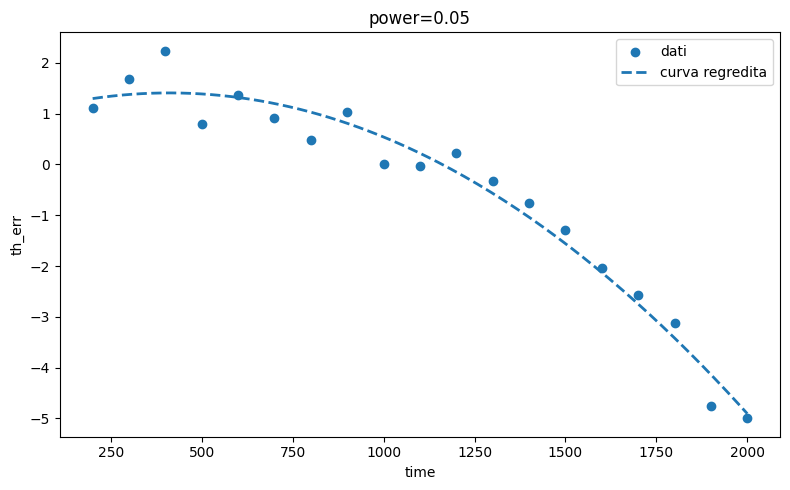

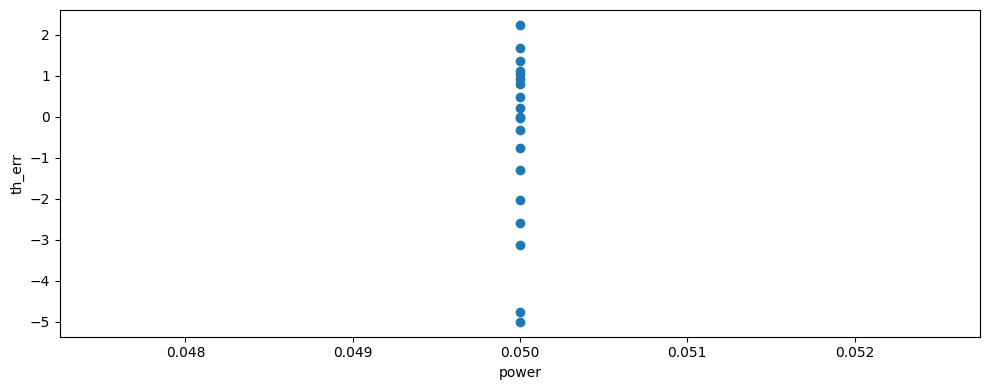

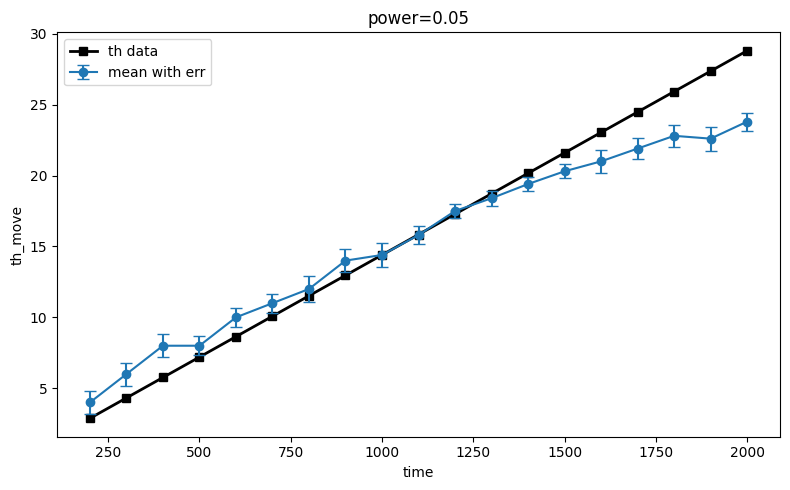

In [15]:
datafile = pd.read_excel("test.ods",engine="odf", sheet_name='Rotate')

#y= mx + q

eff_move=[1,2,3,4,5,6,7,8,9,10]

datafile[eff_move]=datafile[eff_move].apply(pd.to_numeric, errors="coerce")

datafile["th_err"]= datafile[eff_move].mean(axis=1)-datafile["th_move"]
datafile = datafile.dropna(subset=["time", "power","th_move","th_err"] + eff_move)

print(datafile[["time","power","th_move","th_err"]])

x=datafile[["time", "power"]]
y=datafile["th_err"]

x_orig=datafile[["time", "power"]].values

bestdegree=None
bestr2= -9999
bestmodel=None

for degrees in [2,3,4]:
    print(x.shape)
    poly= PolynomialFeatures(degree=degrees)
    x_poly=poly.fit_transform(x_orig)
            
    xtrain ,xtest, ytrain, ytest = train_test_split(x_poly,y, test_size=0.2, random_state=43)
    
    model=LinearRegression()
    model.fit(xtrain,ytrain)

    ypred = model.predict(xtest)
    r2= r2_score(ytest, ypred)
    mae= mean_absolute_error(ytest, ypred)
    mse=mean_squared_error(ytest, ypred)
    rmse= np.sqrt(mse)
    mean_err= np.mean(ypred -ytest)
    print(f"DEGREES: = {degrees}")            
    print("R2: ", r2)
    print("MAE: ", mae)
    print("MSE: ", mse)
    print("RMSE: ", rmse)
    print("MEAN_ERR: ", mean_err)

    if(r2>bestr2):
        bestr2=r2
        bestdegree=degrees

bestpoly=PolynomialFeatures(degree=bestdegree)
x_polybest=bestpoly.fit_transform(x_orig)
model.fit(x_polybest,y)

fig, ax=plt.subplots(figsize=(8,5))
timerange=np.linspace(datafile["time"].min(), datafile["time"].max(), 200)

ax.scatter(datafile["time"],datafile["th_err"], color="tab:blue", label="dati")

x_curve=np.column_stack([timerange, np.full_like(timerange, datafile["power"].iloc[0])])
x_curvepoly=bestpoly.transform(x_curve)
y_curve=model.predict(x_curvepoly)
ax.plot(timerange,y_curve,color="tab:blue", linewidth=2, linestyle="--", label="curva regredita")

ax.set_xlabel("time")
ax.set_ylabel("th_err")
ax.set_title(f"power={datafile['power'].iloc[0]}")
ax.legend()
plt.tight_layout()
plt.show()

fig2, ax2=plt.subplots(figsize=(10,4))
ax2.scatter(datafile["power"],datafile["th_err"])
ax2.set_xlabel("power")
ax2.set_ylabel("th_err")
plt.tight_layout()
plt.show()

datafile["mean"]=datafile[eff_move].mean(axis=1)
datafile["std"]=datafile[eff_move].std(axis=1)

fig3, ax3=plt.subplots(figsize=(8,5))
subset=datafile.sort_values("time")
# th line
ax3.plot(subset["time"], subset["th_move"], color="black", linewidth=2, marker="s",label = "th data")
# eff line with error bar
ax3.errorbar(subset["time"],subset["mean"], yerr=subset["std"],fmt="o-", color="tab:blue", capsize=4, elinewidth=1.5, label="mean with err")

ax3.set_xlabel("time")
ax3.set_ylabel("th_move")
ax3.set_title(f"power={subset['power'].iloc[0]}")
ax3.legend()

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures


#import of model to make sure what model is the best 
from sklearn.ensemble import (GradientBoostingRegressor,HistGradientBoostingRegressor, RandomForestRegressor)

pd.set_option("display.width", 10000)
pd.set_option("display.max_columns", 14)

datafile = pd.read_excel("test.ods",engine="odf", sheet_name='Rotate')

#y= mx + q

eff_move=[1,2,3,4,5,6,7,8,9,10]

datafile[eff_move]=datafile[eff_move].apply(pd.to_numeric, errors="coerce")

datafile["th_err"]= datafile[eff_move].mean(axis=1)-datafile["th_move"]
datafile = datafile.dropna(subset=["time", "power","th_move","th_err"] + eff_move)

print(datafile[["time","power","th_move","th_err"]])

x=datafile[["time", "power"]]
y=datafile["th_err"]

x_orig=datafile[["time", "power"]].values

bestr2= -9999
bestmodel=None

xtrain ,xtest, ytrain, ytest = train_test_split(x_orig,y, test_size=0.2, random_state=43)
        
LR = LinearRegression()
HGBR=HistGradientBoostingRegressor()
GBR=GradientBoostingRegressor()
RFR=RandomForestRegressor(n_jobs=-1)

#best model check to make sure linear regression is the best model
for model in [LR,GBR,HGBR,RFR]:
    model.fit(xtrain,ytrain)
    ypred = model.predict(xtest)
    r2= r2_score(ytest, ypred)
    mae=mean_absolute_error(ytest,ypred)
    rmse=np.sqrt(mean_squared_error(ytest,ypred))

    if r2>bestr2:
        bestr2 = r2
        bestmodel= model
        bestmae=mae
        bestrmse=rmse

print("best model: ", bestmodel)
print("R2: ", r2)
print("MAE: ", mae)
print("RMSE: ", rmse)

      time  power  th_move  th_err
1    200.0   0.05     2.88    1.12
2    300.0   0.05     4.32    1.68
3    400.0   0.05     5.76    2.24
4    500.0   0.05     7.20    0.80
5    600.0   0.05     8.64    1.36
6    700.0   0.05    10.08    0.92
7    800.0   0.05    11.52    0.48
8    900.0   0.05    12.96    1.04
9   1000.0   0.05    14.40    0.00
10  1100.0   0.05    15.84   -0.04
11  1200.0   0.05    17.28    0.22
12  1300.0   0.05    18.72   -0.32
13  1400.0   0.05    20.16   -0.76
14  1500.0   0.05    21.60   -1.30
15  1600.0   0.05    23.04   -2.04
16  1700.0   0.05    24.48   -2.58
17  1800.0   0.05    25.92   -3.12
18  1900.0   0.05    27.36   -4.76
19  2000.0   0.05    28.80   -5.00
best model:  GradientBoostingRegressor()
R2:  0.916593021898441
MAE:  0.5315000000000001
RMSE:  0.621154038866368
